In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
from HighLevelFeatures import HighLevelFeatures as HLF
import numpy as np
import h5py
import matplotlib.pyplot as plt
from model import WGANGP
from train import *
from common import *
from evaluate import *
from common import _split_energy


2023-08-20 16:46:54.678781: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-08-20 16:46:54.678804: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


## Plot statistics

In [61]:
# photon_file = h5py.File(f'{input_path}/dataset_1_photons_1.hdf5', 'r')
# pion_file = h5py.File(f'{input_path}/dataset_1_pions_1.hdf5', 'r')

photon_file = h5py.File(f'../output/dataset1/v1/splitJuly/gan_3energy_split.h5', 'r')
pion_file = h5py.File(f'../output/dataset1/v1/splitJuly/gan_2energy_split.h5', 'r')

energies1 = photon_file['incident_energies'][:]
energies2 = pion_file['incident_energies'][:]


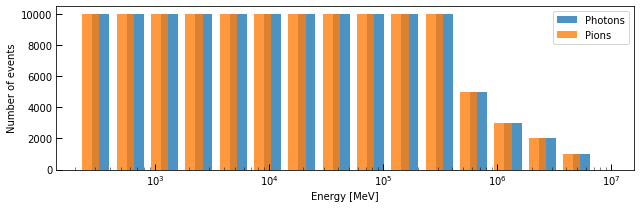

In [62]:
bins = np.logspace(8,23,31, base=2)
fig, ax = plt.subplots(figsize=(9, 3))
plt.hist(energies1*1.1, bins=bins*1.1, alpha=0.8, label='Photons')
plt.hist(energies2*0.9, bins=bins*0.9, alpha=0.8, label='Pions')
plt.xscale('log')
plt.xlabel('Energy [MeV]')
plt.ylabel('Number of events')
plt.tick_params(axis="both", which="major", width=1, length=6, labelsize=10, direction="in")
plt.tick_params(axis="both", which="minor", width=0.5, length=3, labelsize=10, direction="in")
plt.legend()
plt.tight_layout()
plt.savefig('statistics.pdf')
plt.show()

## Validate h5 file generated from best model

In [5]:
input_data = h5py.File(f'../input/dataset1/dataset_1_pions_1.hdf5', 'r')
input_incident = input_data['incident_energies'][:]
input_shower = input_data['showers'][:]

In [6]:
# output_data = h5py.File(f'../output/dataset1/v2/BNswish_hpo4-M1/photons_eta_20_25/selected/h5/gan.h5', 'r')
output_data = h5py.File(f'../output/dataset1/v1/BNReLUCustActiv_hpo27-M-Pnormlayer2.2/pions_eta_20_25/selected/h5/gan.h5', 'r')
# output_data = h5py.File(f'../output/dataset1/v1/BNswish_hpo101-M-P-L-Sge12/photons_eta_20_25/selected/h5/gan.h5', 'r')
# output_data = h5py.File(f'../output/dataset1/v1/splitJuly/gan_2energy_split.h5', 'r')
# output_data = h5py.File(f'../output/dataset1/v1/splitJuly/gan_3energy_split.h5', 'r')

output_incident = output_data['incident_energies'][:]
output_shower = output_data['showers'][:]

In [7]:
input_shower.shape, output_shower.shape

((120800, 533), (120800, 533))

In [8]:
input_shower_small = input_shower[input_incident.flatten() == 4194304]
output_shower_small = output_shower[output_incident.flatten() == 4194304]
input_shower_small.shape, output_shower_small.shape

((1000, 533), (1000, 533))

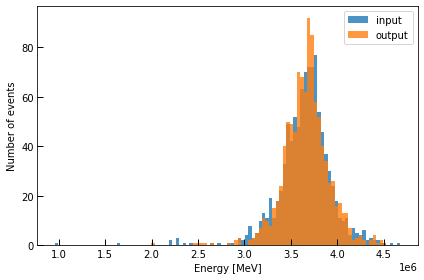

In [9]:
# bins = np.logspace(8,23,31, base=2)
n, bins, _ = plt.hist(input_shower_small.sum(axis=1), bins=100, alpha=0.8, label='input')
plt.hist(output_shower_small.sum(axis=1), bins=bins, alpha=0.8, label='output')
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Energy [MeV]')
plt.ylabel('Number of events')
plt.tick_params(axis="both", which="major", width=1, length=6, labelsize=10, direction="in")
plt.tick_params(axis="both", which="minor", width=0.5, length=3, labelsize=10, direction="in")
plt.legend()
plt.tight_layout()
plt.show()

## Merge splitted energy

In [3]:
def merge_dataset(keep_incident, keep_shower, remove_incident, remove_shower):
    common = np.intersect1d(np.unique(keep_incident), np.unique(remove_incident))
    remove_shower_new = remove_shower[remove_incident.flatten() != common]
    remove_incident_new = remove_incident[remove_incident.flatten() != common]
    if remove_incident_new.shape[0] == 1:
        remove_incident_new = remove_incident_new[0]
        remove_shower_new = remove_shower_new[0]
    return np.concatenate((keep_incident, remove_incident_new)), np.concatenate((keep_shower, remove_shower_new))

def gen_h5(energies, showers, output):
    os.makedirs(os.path.dirname(output), exist_ok=True)
    dataset_file = h5py.File(output, 'w')
    energies = np.array(energies)
    showers  = np.array(showers)
    dataset_file.create_dataset('incident_energies', data=energies.reshape(len(energies), -1), compression='gzip')
    dataset_file.create_dataset('showers', data=showers.reshape(len(showers), -1), compression='gzip')
    print('Save h5 file to', output)
    dataset_file.close()

In [59]:
#output_data1 = h5py.File(f'../output/dataset1/v1/BNLeakyReLU_hpo31-M-P-L-Sle12.3/photons_eta_20_25/selected/h5/gan.h5', 'r')
#output_data2 = h5py.File(f'../output/dataset1/v1/BNswish_hpo101-M-P-L-Sge12/photons_eta_20_25/selected/h5/gan.h5', 'r')
#output_data3 = h5py.File(f'../output/dataset1/v1/BNswish_hpo101-M-P-L-Sge12le18.2/photons_eta_20_25/selected/h5/gan.h5', 'r')
#output_data4 = h5py.File(f'../output/dataset1/v1/BNswish_hpo101-M-P-L-Sge18/photons_eta_20_25/selected/h5/gan.h5', 'r')
low12 = f'../output/dataset1/v1/BNswishCustActiv_hpo113-M-Pnormlayer2-L-Sle12.1/photons_eta_20_25/selected/h5/gan.h5'
high12 = f'../output/dataset1/v1/BNswishCustActiv_hpo113-M-Pnormlayer2-L-Sge12/photons_eta_20_25/selected/h5/gan.h5'
high12low18 = f'../output/dataset1/v1/BNswishCustActiv_hpo113-M-Pnormlayer2-L-ge12le18.1/photons_eta_20_25/selected/h5/gan.h5'
high18 = f'../output/dataset1/v1/BNswishCustMichele_hpo117-M-PnormlayerMichele-L-ge18.Michele/photons_eta_20_25/selected/h5/gan.h5'
output_data1 = h5py.File(low12, 'r')
output_data2 = h5py.File(high12, 'r')
output_data3 = h5py.File(high12low18, 'r')
output_data4 = h5py.File(high18, 'r')
output = '../output/dataset1/v1/splitJuly/'

###########  1      2       3         4
###########  le12   ge12    ge12le18  g18
## 4.1 MeV   1.9    2.2     2.1
## 262.1GeV                 2.5       2.0

keep_incident = output_data2['incident_energies'][:]
keep_shower = output_data2['showers'][:]
remove_incident = output_data1['incident_energies'][:]
remove_shower = output_data1['showers'][:]
energies, showers = merge_dataset(keep_incident, keep_shower, remove_incident, remove_shower)
gen_h5(energies, showers, os.path.join(output, 'gan_2energy_split.h5'))



Save h5 file to ../output/dataset1/v1/splitJuly/gan_2energy_split.h5


In [60]:
keep_incident = output_data3['incident_energies'][:]
keep_shower = output_data3['showers'][:]
remove_incident = output_data1['incident_energies'][:]
remove_shower = output_data1['showers'][:]
remove2_incident, remove2_shower = merge_dataset(keep_incident, keep_shower, remove_incident, remove_shower)

keep2_incident = output_data4['incident_energies'][:]
keep2_shower = output_data4['showers'][:]
remove2_incident, remove2_shower = merge_dataset(keep2_incident, keep2_shower, remove2_incident, remove2_shower)

gen_h5(energies, showers, os.path.join(output, 'gan_3energy_split.h5'))



Save h5 file to ../output/dataset1/v1/splitJuly/gan_3energy_split.h5
